<a href="https://colab.research.google.com/github/abhishekanand04/Intro-to-ML-and-NN/blob/machinelearning/Linear_Regression1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
!gdown 1qXoDeYVC4vhd7xTNwohxh9dMCjjtoHoJ



Downloading...
From: https://drive.google.com/uc?id=1qXoDeYVC4vhd7xTNwohxh9dMCjjtoHoJ
To: /content/cars24-car-price-cleaned-new.csv
100% 1.55M/1.55M [00:00<00:00, 41.8MB/s]


In [ ]:
df = pd.read_csv('cars24-car-price-cleaned-new.csv')
df.head()

,selling_price,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,1.20,120000,19.70,796.0,46.30,11.0,MARUTI,ALTO STD,1,0,0,0,0,1,1,1,0
1,5.50,20000,18.90,1197.0,82.00,7.0,HYUNDAI,GRAND I10 ASTA,1,0,0,0,0,1,1,1,0
2,2.15,60000,17.00,1197.0,80.00,13.0,HYUNDAI,I20 ASTA,1,0,0,0,0,1,1,1,0
3,2.26,37000,20.92,998.0,67.10,11.0,MARUTI,ALTO K10 2010-2014 VXI,1,0,0,0,0,1,1,1,0
4,5.70,30000,22.77,1498.0,98.59,8.0,FORD,ECOSPORT 2015-2021 1.5 TDCI TITANIUM BSIV,0,0,1,0,0,0,1,1,0


In [ ]:
df['model'].nunique()

3233

In [ ]:
df['make'].nunique()

41

In [ ]:
df['make'] = df.groupby('make')['selling_price'].transform('mean')
df['model'] = df.groupby('model')['selling_price'].transform('mean')
df.head()

,selling_price,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,1.20,120000,19.70,796.0,46.30,11.0,4.684721,1.180000,1,0,0,0,0,1,1,1,0
1,5.50,20000,18.90,1197.0,82.00,7.0,5.458819,4.818750,1,0,0,0,0,1,1,1,0
2,2.15,60000,17.00,1197.0,80.00,13.0,5.458819,3.394000,1,0,0,0,0,1,1,1,0
3,2.26,37000,20.92,998.0,67.10,11.0,4.684721,2.242676,1,0,0,0,0,1,1,1,0
4,5.70,30000,22.77,1498.0,98.59,8.0,5.858258,6.777576,0,0,1,0,0,0,1,1,0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
df.head()

,selling_price,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,0.043684,0.031553,0.135345,0.117891,0.066506,0.310345,0.194048,0.041550,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
1,0.252397,0.005237,0.128448,0.177281,0.123994,0.172414,0.232517,0.218382,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
2,0.089795,0.015764,0.112069,0.177281,0.120773,0.379310,0.232517,0.149143,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
3,0.095134,0.009711,0.145862,0.147808,0.100000,0.310345,0.194048,0.093193,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
4,0.262104,0.007869,0.161810,0.221860,0.150709,0.206897,0.252367,0.313574,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


In [ ]:
df1 = pd.read_csv('cars24-car-price-cleaned-new.csv')

In [ ]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df1, test_size=0.3, random_state=1)

In [ ]:
df_train.shape

(13874, 17)

In [ ]:
df_test.shape

(5946, 17)

In [ ]:
make_category_wise_mean = df_train.groupby('make')['selling_price'].mean()
model_category_wise_mean = df_train.groupby('model')['selling_price'].mean()

df_train['make'] = df_train.groupby('make')['selling_price'].transform('mean')
df_train['model'] = df_train.groupby('model')['selling_price'].transform('mean')


df_test['make'] = df_test['make'].map(make_category_wise_mean)
df_test['model'] = df_test['model'].map(model_category_wise_mean)

In [ ]:
df_test.isna().sum()

,0
selling_price,0
km_driven,0
mileage,0
engine,0
max_power,0
age,0
make,5
model,468
Individual,0
Trustmark Dealer,0


In [ ]:
global_mean = df_train['selling_price'].mean()

In [ ]:
df_test['make'] = df_test['make'].fillna(global_mean)
df_test['model'] = df_test['model'].fillna(global_mean)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_train = pd.DataFrame(scaler.fit_transform(df_train), columns=df_train.columns)

df_test = pd.DataFrame(scaler.transform(df_test), columns=df_train.columns)

In [ ]:
y_train = df_train['selling_price']
X_train = df_train.drop('selling_price', axis=1)
y_train.shape, X_train.shape

((13874,), (13874, 16))

In [ ]:
y_test = df_test['selling_price']
X_test = df_test.drop('selling_price', axis=1)
y_test.shape, X_test.shape

((5946,), (5946, 16))

In [ ]:
X_train

,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,0.001163,0.182500,0.118335,0.077778,0.24,0.164123,0.139801,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
1,0.005637,0.110086,0.443276,0.413027,0.20,0.805756,1.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.013007,0.136810,0.216380,0.126892,0.16,0.164123,0.348682,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
3,0.027220,0.103103,0.373667,0.091948,0.32,0.301690,0.253502,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
4,0.013600,0.154310,0.206754,0.134879,0.36,0.204876,0.201272,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13869,0.005111,0.164655,0.147808,0.099903,0.08,0.166142,0.217066,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
13870,0.010375,0.118966,0.177429,0.131562,0.16,0.231209,0.239112,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
13871,0.007743,0.182500,0.118335,0.077778,0.20,0.164123,0.138874,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
13872,0.014060,0.069397,0.322719,0.185185,0.36,0.301690,0.225165,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0


In [ ]:
X1_train = X_train[['model']]
X1_test = X_test[['model']]

### Univariate  
  X1_train contain only 1 feature.

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X1_train, y_train)

LinearRegression()

In [ ]:
model.coef_

array([0.99878656])

In [ ]:
model.intercept_

np.float64(0.0012134449702706496)

In [ ]:
y_hat = model.predict(X_test[['model']])

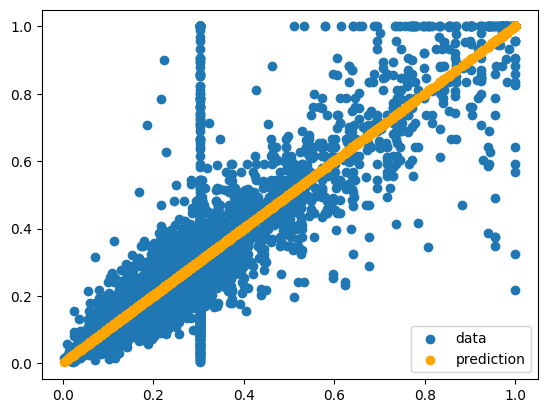

In [ ]:
fig = plt.figure()
plt.scatter(X_test[['model']],y_test,label='data')
plt.scatter(X_test[['model']],y_hat,color='orange',label='prediction')
plt.legend()
plt.show()

### Multivariate

  X_train consist of all features

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
model.coef_

array([-0.22864076, -0.22718566,  0.06493271,  0.04101896, -0.20803904,
        0.06292526,  0.8680704 , -0.00692582, -0.00676553,  0.00537632,
        0.13338991,  0.01451176, -0.00704768, -0.0039257 , -0.01313206,
       -0.02020274])

In [ ]:
model.intercept_

np.float64(0.11212257190753999)

In [ ]:
X_test

,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,0.018271,0.112069,0.160841,0.000000,0.48,0.204876,0.303310,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,0.015113,0.182759,0.184834,0.111111,0.24,0.166142,0.212577,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0.013007,0.183793,0.177429,0.115942,0.16,0.301690,0.275787,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,0.018797,0.110345,0.221712,0.181965,0.44,0.231209,0.155753,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.018271,0.194741,0.184834,0.111111,0.24,0.166142,0.239897,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5941,0.014060,0.187931,0.221860,0.150725,0.12,0.231209,0.184425,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
5942,0.015113,0.090776,0.265699,0.214332,0.48,0.462205,0.373196,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
5943,0.013007,0.120690,0.147364,0.091787,0.36,0.059089,0.046356,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
5944,0.020903,0.110345,0.221712,0.181965,0.44,0.231209,0.140931,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [ ]:
y_hat = model.predict(X_test)

In [ ]:
y_hat

array([0.2452726 , 0.21708234, 0.29001806, ..., 0.04002231, 0.12237877,
       0.5204461 ])

In [ ]:
pd.DataFrame(X_test.iloc[0,:]).T

,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,0.018271,0.112069,0.160841,0.0,0.48,0.204876,0.30331,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [ ]:
y_hat = model.predict(pd.DataFrame(X_test.iloc[0,:]).T)

In [ ]:
y_hat

array([0.2452726])